# Data Importing and Preprocessing

In [39]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score



## 2. Load the Dataset

In [40]:
df = pd.read_csv("data/raw_data/car_price.csv")
df.head()



,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,Make
0,A1,2017.0,12500.0,Manual,15735.0,Petrol,150.0,55.4,1.4,audi
1,A6,2016.0,16500.0,Automatic,36203.0,Diesel,20.0,64.2,2.0,audi
2,A1,2016.0,11000.0,Manual,29946.0,Petrol,30.0,55.4,1.4,audi
3,A4,2017.0,16800.0,Automatic,25952.0,Diesel,145.0,67.3,2.0,audi
4,A3,2019.0,17300.0,Manual,1998.0,Petrol,145.0,49.6,1.0,audi


In [41]:
df.shape


(72435, 10)

## Task 1:

## 3. Exploratory Data Analysis (EDA)

In [42]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 72435 entries, 0 to 72434
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   model         68814 non-null  str    
 1   year          68813 non-null  float64
 2   price         68814 non-null  float64
 3   transmission  68812 non-null  str    
 4   mileage       68813 non-null  float64
 5   fuelType      68813 non-null  str    
 6   tax           68814 non-null  float64
 7   mpg           68814 non-null  float64
 8   engineSize    68813 non-null  float64
 9   Make          68814 non-null  str    
dtypes: float64(6), str(4)
memory usage: 5.5 MB


In [43]:
df.describe()

,year,price,mileage,tax,mpg,engineSize
count,68813.000000,68814.000000,68813.000000,68814.000000,68814.000000,68813.000000
mean,2017.077660,16583.919261,23179.439539,116.930421,55.836352,1.635373
std,2.099474,9304.412707,21347.569657,64.081931,17.043643,0.561734
min,1996.000000,495.000000,1.000000,0.000000,0.300000,0.000000
25%,2016.000000,10167.250000,7199.000000,30.000000,47.900000,1.200000
50%,2017.000000,14495.000000,17521.000000,145.000000,55.400000,1.600000
75%,2019.000000,20359.750000,32478.000000,145.000000,62.800000,2.000000
max,2020.000000,145000.000000,323000.000000,580.000000,470.800000,6.600000


## 4. Determining which features are numerical and Which are categorical

In [44]:
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns
categorical_cols = df.select_dtypes(include=['object']).columns
print("Numerical Features:",numerical_cols)
print("\nCategorical Features:",categorical_cols)

Numerical Features: Index(['year', 'price', 'mileage', 'tax', 'mpg', 'engineSize'], dtype='str')

Categorical Features: Index(['model', 'transmission', 'fuelType', 'Make'], dtype='str')


/tmp/ipykernel_67653/3944902702.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include=['object']).columns


## 5. Checking null values

In [45]:
df.isna().sum()

model           3621
year            3622
price           3621
transmission    3623
mileage         3622
fuelType        3622
tax             3621
mpg             3621
engineSize      3622
Make            3621
dtype: int64

## 6.The distribution of car prices 

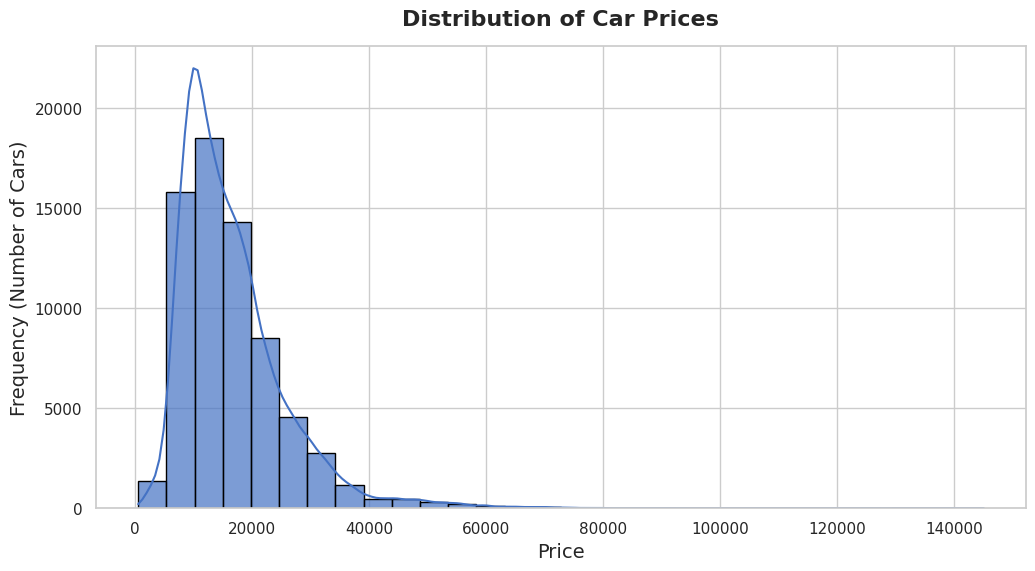

In [46]:
sns.set_theme(style="whitegrid")

plt.figure(figsize=(12, 6))

sns.histplot(df['price'], bins=30, kde=True, color="#4472c4", edgecolor="black", alpha=0.7)

plt.title('Distribution of Car Prices', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Price', fontsize=14)
plt.ylabel('Frequency (Number of Cars)', fontsize=14)

plt.show()

## 7.Which features seem most related to price? 

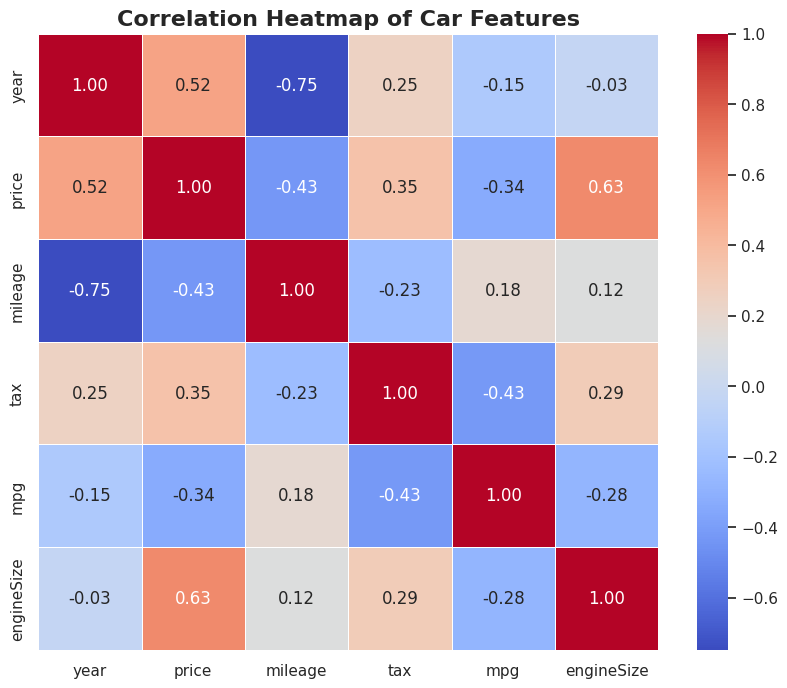

Features most related to price:
price         1.000000
engineSize    0.629839
year          0.519383
tax           0.353204
mpg          -0.335615
mileage      -0.427524
Name: price, dtype: float64


In [47]:

correlation_matrix = df[numerical_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)


plt.title('Correlation Heatmap of Car Features', fontsize=16, fontweight='bold')
plt.show()

print("Features most related to price:")
print(correlation_matrix['price'].sort_values(ascending=False))

## Task 2:
## 8.Handle missing values


In [48]:
df.dropna(subset=['price'], inplace=True)

cat_cols = df.select_dtypes(include=['object']).columns
for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

num_cols = df.select_dtypes(include=['number']).columns
for col in num_cols:
    df[col] = df[col].fillna(df[col].median())

print(df.isna().sum())



model           0
year            0
price           0
transmission    0
mileage         0
fuelType        0
tax             0
mpg             0
engineSize      0
Make            0
dtype: int64


/tmp/ipykernel_67653/1772317732.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include=['object']).columns


## 9.Encode categorical columns



In [49]:
categorical_cols = ['Make', 'model', 'transmission', 'fuelType']
enc = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
encoded_data = enc.fit_transform(df[categorical_cols])
encoded_df = pd.DataFrame(encoded_data, columns=enc.get_feature_names_out(categorical_cols))
df = df.drop(categorical_cols, axis=1)
df = pd.concat([df, encoded_df], axis=1)
df.head()



,year,price,mileage,tax,mpg,engineSize,Make_BMW,Make_Ford,Make_Hyundai,Make_audi,...,model_ i8,transmission_Automatic,transmission_Manual,transmission_Other,transmission_Semi-Auto,fuelType_Diesel,fuelType_Electric,fuelType_Hybrid,fuelType_Other,fuelType_Petrol
0,2017.0,12500.0,15735.0,150.0,55.4,1.4,0.0,0.0,0.0,1.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1,2016.0,16500.0,36203.0,20.0,64.2,2.0,0.0,0.0,0.0,1.0,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
2,2016.0,11000.0,29946.0,30.0,55.4,1.4,0.0,0.0,0.0,1.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3,2017.0,16800.0,25952.0,145.0,67.3,2.0,0.0,0.0,0.0,1.0,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
4,2019.0,17300.0,1998.0,145.0,49.6,1.0,0.0,0.0,0.0,1.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


## 10.scaling numerical features

In [50]:
num_cols = ['year', 'engineSize','mpg','tax','mileage']
scaler = StandardScaler()
df[num_cols] = scaler.fit_transform(df[num_cols])
df.head()


,year,price,mileage,tax,mpg,engineSize,Make_BMW,Make_Ford,Make_Hyundai,Make_audi,...,model_ i8,transmission_Automatic,transmission_Manual,transmission_Other,transmission_Semi-Auto,fuelType_Diesel,fuelType_Electric,fuelType_Hybrid,fuelType_Other,fuelType_Petrol
0,-0.035083,12500.0,-0.343817,0.503715,-0.024092,-0.427643,0.0,0.0,0.0,1.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1,-0.522998,16500.0,0.637381,-1.566715,0.503152,0.669878,0.0,0.0,0.0,1.0,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
2,-0.522998,11000.0,0.337432,-1.407451,-0.024092,-0.427643,0.0,0.0,0.0,1.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3,-0.035083,16800.0,0.145967,0.424083,0.688886,0.669878,0.0,0.0,0.0,1.0,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
4,0.940747,17300.0,-1.002342,0.424083,-0.371594,-1.159324,0.0,0.0,0.0,1.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


## 11.Detect and handle outliers 

In [51]:
# --- IQR method 
cols_to_clean = ['price', 'mileage', 'engineSize', 'mpg']

for col in cols_to_clean:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    df = df[(df[col] >= lower_bound) & (df[col] <= upper_bound)]

print(f"New shape after cleaning outliers: {df.shape}")

New shape after cleaning outliers: (62423, 167)


## Task 3:
## A. Regression Target (Linear Regression)   

Linear Regression performance on test set:
  RMSE: 3151.57
  R^2: 0.7847

Top features by coefficient magnitude:
                    feature   coefficient
153               model_ Z3  10550.962048
51               model_ Eos  -5608.498214
44        model_ California  -4672.323397
123          model_ Shuttle  -4247.766594
41        model_ Caddy Life  -4236.466829
132  model_ Tiguan Allspace  -4135.806134
56               model_ Fox  -3985.107883
40             model_ Caddy  -3927.548292
75             model_ Jetta  -3909.674544
48           model_ Corolla  -3794.320752


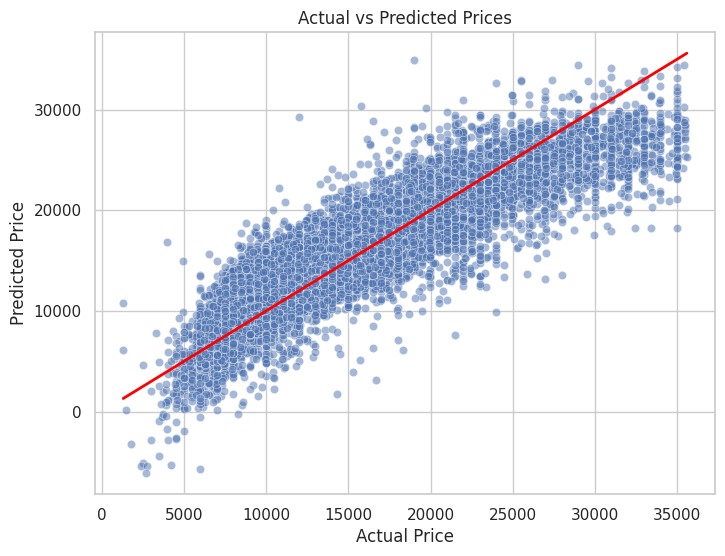

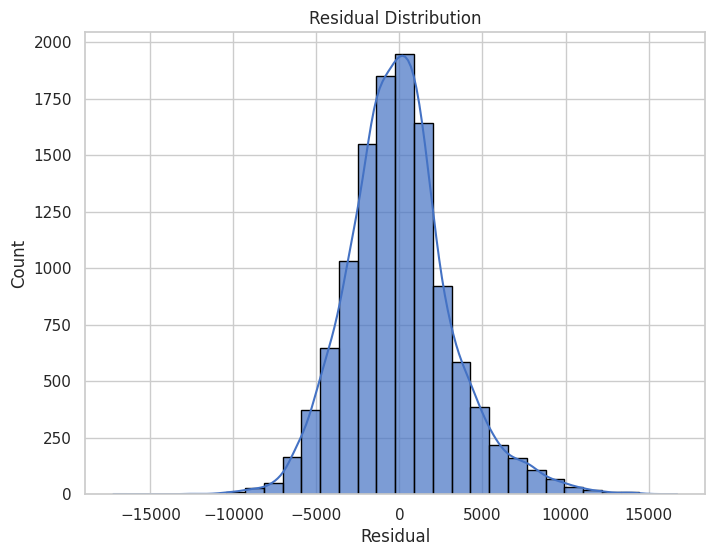

In [ ]:
# Define target and feature set
X = df.drop(columns=['price'])
y = df['price']

# Train/test split FIRST
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

use a real-world car dataset to solve two machine learning problems
using the same data and preprocessing pipeline:
- Regression — predict the exact selling price of a car
- Classification — group cars into price categories (Cheap, Moderate, Expensive)

# Now train the model
model = LinearRegression()
model.fit(X_train, y_train)

# Predict on the test set
y_pred = model.predict(X_test)

# Evaluate the model
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f'Linear Regression performance on test set:')
print(f'  RMSE: {rmse:.2f}')
print(f'  R^2: {r2:.4f}')

# Show the top coefficients by absolute value
coef_df = pd.DataFrame({ 'feature': X_train.columns, 'coefficient': model.coef_ })
coef_df['abs_coefficient'] = coef_df['coefficient'].abs()
coef_df = coef_df.sort_values(by='abs_coefficient', ascending=False).drop(columns='abs_coefficient')
print('\nTop features by coefficient magnitude:')
print(coef_df.head(10))

# Plot predictions versus actual values
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linewidth=2)
plt.title('Actual vs Predicted Prices')
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.show()

# Plot residuals
residuals = y_test - y_pred
plt.figure(figsize=(8, 6))
sns.histplot(residuals, bins=30, kde=True, color='#4472c4', edgecolor='black', alpha=0.7)
plt.title('Residual Distribution')
plt.xlabel('Residual')
plt.ylabel('Count')
plt.show()
